# Large spatial scale extraction of velocity fields

If your goal requires to examine velocity fields over large spatial areas, especially if you require few epochs, then it makes sense to use the Zarr store optimized for this type of operation.

The Greenland Zarr store suitable for this analysis is called `greenland_multisource_velocity_spatial.zarr` whilst the Antarctic equivalent is called `antarctica_multisource_velocity_spatial.zarr` and their equivalent URLs are:


In [1]:
# Greenland URL
greenland_url = "https://data.source.coop/uos-shiver/greenland/greenland_multisource_velocity_spatial.zarr"

# Antarctica URL
antarctica_url = "https://data.source.coop/uos-shiver/antarctica/antarctica_multisource_velocity_spatial.zarr"


These are `OME-Zarr` stores, which are analagous to Cloud Optimized Geotiffs for Zarr. They contain multiple copies of the velocity data at varying spatial resolutions. At the lowest level (group 0), the resolution is 200 m, whereas at the highest level (group 4 for Greenland and group 5 for Antarctica) the resolution is 3200 m for Greenland and 6400 m for Antarctica. If your analysis does not require the highest spatial resolution, you can save yourself significant resources by using one of the lower resolution layers.

In this example, we will visualise a large-scale velocity field of Greenland. Since plots (even those produced at a high dpi and viewed on a high spec monitor) are lower resolution than our data, it is a waste of resources to use the full resolution layer. Therefore, we will use lowest resolution layer, which we can do simply by specify the group number in our open_zarr call.

In [2]:
import matplotlib.pyplot as plt
import zarr
import xarray as xr

# Load the lower spatial resolution layer lazily
ds = xr.open_zarr(greenland_url, group="4", consolidated=True, )

We can filter the Zarr to target a particular Contributing Dataset. Since we want a relatively complete velocity field for this example, we will visualise the most recent `MEaSUREs annual` velocity field. 

In [3]:
# Identify only measures multiyear data
source_mask = (ds['data_source'] == 'MEaSUREs_annual').compute()

# Apply the mask to the lazy time array
measures_times = ds.time[source_mask]

# 4. Select the last (most recent) matching epoch
latest_time = measures_times[-1]

# Slice the lazy dataset for the 'speed' variable and compute (download) it
speed_data_local = ds['speed'].sel(time=latest_time).compute()

Then plot the velocity field.

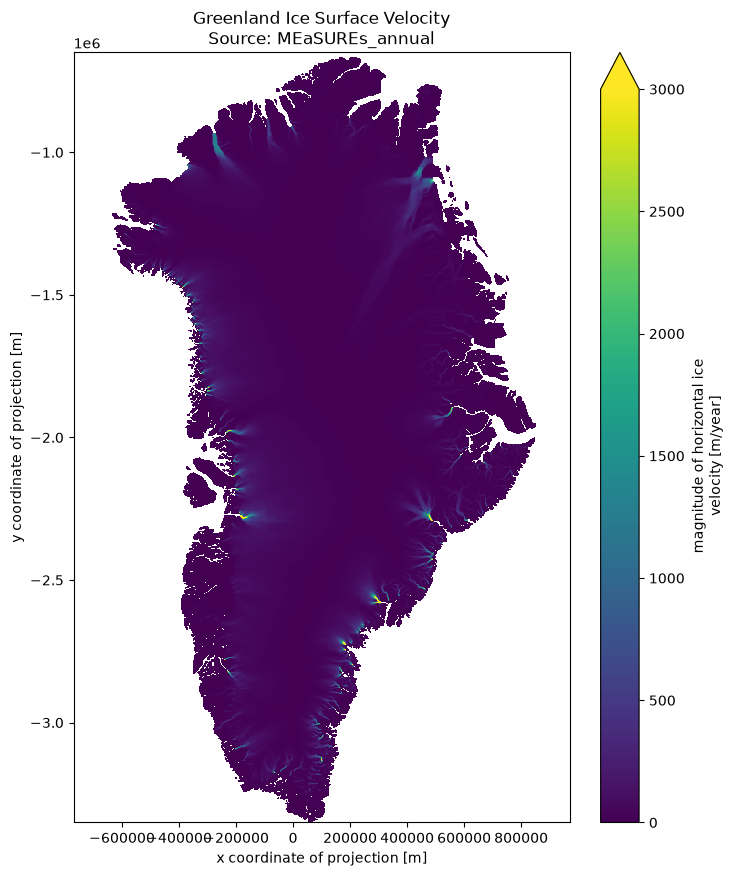

In [4]:
# Plot the full ice sheet
plt.figure(figsize=(8, 10))
speed_data_local.plot(cmap="viridis", vmin=0, vmax=3000)
plt.title(f"Greenland Ice Surface Velocity\nSource: MEaSUREs_annual")
plt.axis("equal")
plt.show()

It is quite common to require closer examination of small regions. In this case, it makes sense to use one of the higher resolution OME-Zarr groups, or even the highest resolution group. 

Let's take a closer look at the velocity field just north of Jakobshavn Isbrae in west Greenland, containing the termini of Sermeq Kujalleq, Sermeq Avannarleq, Kangilernata Sermia and Eqip Sermia.

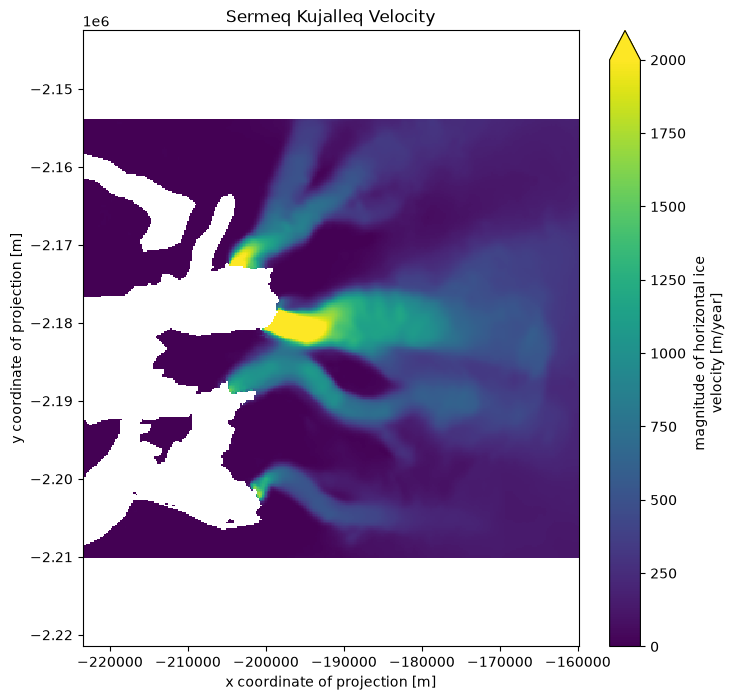

In [6]:
from pyproj import Transformer  

# Load the higher spatial resolution layer lazily
ds_hr = xr.open_zarr(greenland_url, group="0", consolidated=True)

# Convert Geographic coordinates (lon/lat) to Polar Stereographic (EPSG:3413)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3413", always_xy=True)
lon_top_left, lat_top_left = -50.9249, 70.2013
lon_bot_right, lat_bot_right = -49.1396, 69.7488
xmin, ymax = transformer.transform(lon_top_left, lat_top_left)
xmax, ymin = transformer.transform(lon_bot_right, lat_bot_right)

# Find the most recent MEaSUREs_multiyear epoch
source_mask = (ds_hr['data_source'] == 'MEaSUREs_annual').compute()
latest_time = ds_hr.time[source_mask][-1]

# Handle Y-axis orientation for slicing
y_slice = slice(ymax, ymin) if ds_hr.y[0] > ds_hr.y[-1] else slice(ymin, ymax)

# Crop time and space lazily, then download the target area
sermeq_map = ds_hr['speed'].sel(
    time=latest_time,
    x=slice(xmin, xmax), 
    y=y_slice
).compute() 

# 6. Plot and Save
plt.figure(figsize=(8, 8))
sermeq_map.plot(cmap="viridis", vmin=0, vmax=2000)
plt.title("Sermeq Kujalleq Velocity")
plt.axis("equal")
plt.show()